In [ ]:
from pathlib import Path

# --- Video ---
YOUTUBE_URL = "https://youtu.be/IhLSLGx2hok?si=lPR_E4_eUcmfwmmq"  # Change this to any video with two or more speakers

# --- Working directory ---
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

# --- Whisper (if no transcript is available) ---
WHISPER_MODEL_SIZE = "small"   # Suitable for RTX 3050 Laptop (4GB VRAM). Try "base" for faster speed
WHISPER_LANGUAGES_FOR_CAPTIONS = ("ar", "en")  # Preferred languages if YouTube captions are available

# --- Text chunking and summarization ---
CHUNK_WORDS = 500
OVERLAP_WORDS = 50
SUMMARY_MODEL = "qwen3.5:4b"  # The same model used with Ollama

# --- Speaker Diarization / Clustering ---
TARGET_SR = 16_000
MAX_SPEAKERS = 6
KMEANS_SEED = 42
N_PLAY_PER_SPEAKER = 3
MAX_SPEECH_SEC = 10
MIN_SPEECH_SEC = 0.5

print("Config is ready")

Config جاهزة


In [3]:
# %pip install -U yt-dlp youtube-transcript-api faster-whisper ollama silero-vad speechbrain scikit-learn torchaudio matplotlib


In [4]:
%pip install silero-vad

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install speechbrain

Note: you may need to restart the kernel to use updated packages.


In [4]:
from __future__ import annotations

import re
import random
from dataclasses import dataclass

import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from torchaudio.transforms import Resample

from silero_vad import get_speech_timestamps, load_silero_vad
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from speechbrain.inference.speaker import EncoderClassifier

from ollama import chat

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [7]:
%pip install yt-dlp

Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install faster-whisper

Note: you may need to restart the kernel to use updated packages.


In [ ]:
YOUTUBE_URL_PATTERN = re.compile(
    r"(?:https?://)?(?:www\.)?(?:youtube\.com/watch\?v=|youtu\.be/|youtube\.com/shorts/)([\w-]{11})"
)


def validate_youtube_url(url: str) -> bool:
    return bool(YOUTUBE_URL_PATTERN.search(url))


def extract_video_id(url: str) -> str | None:
    match = YOUTUBE_URL_PATTERN.search(url)
    return match.group(1) if match else None


print("valid:", validate_youtube_url(YOUTUBE_URL))
print("video_id:", extract_video_id(YOUTUBE_URL))


valid: True
video_id: IhLSLGx2hok


In [6]:
import yt_dlp


def download_audio(video_id: str, out_dir: Path = DATA_DIR) -> tuple[Path, str]:
    out_template = str(out_dir / f"{video_id}.%(ext)s")

    ydl_opts = {
        "format": "bestaudio/best",
        "outtmpl": out_template,
        "ffmpeg_location": r"D:\OneDrive\Documents\GitHub\summer-intern-2026-02\Abdalah anwer\ffmpeg-8.1.2-essentials_build\ffmpeg-8.1.2-essentials_build\bin",
        "postprocessors": [{
            "key": "FFmpegExtractAudio",
            "preferredcodec": "wav",
            "preferredquality": "192",
        }],
        "quiet": True,
        "no_warnings": True,
    }

    url = f"https://www.youtube.com/watch?v={video_id}"
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        title = info.get("title", video_id)

    audio_path = out_dir / f"{video_id}.wav"
    return audio_path, title


In [7]:
def fetch_youtube_transcript(video_id: str, languages=WHISPER_LANGUAGES_FOR_CAPTIONS):
    try:
        from youtube_transcript_api import YouTubeTranscriptApi
    except ImportError:
        return None

    # نسخ حديثة من المكتبة (instance-based)
    try:
        api = YouTubeTranscriptApi()
        fetched = api.fetch(video_id, languages=list(languages))
        return [{"text": s.text, "start": s.start, "duration": s.duration} for s in fetched]
    except AttributeError:
        pass
    except Exception:
        pass

    # نسخ قديمة (static method)
    try:
        raw = YouTubeTranscriptApi.get_transcript(video_id, languages=list(languages))
        return [{"text": s["text"], "start": s["start"], "duration": s["duration"]} for s in raw]
    except Exception:
        return None


def clean_transcript_text(text: str) -> str:
    text = re.sub(r"\[.*?\]", " ", text)  # يشيل [Music]، [Applause]، إلخ
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [8]:
from faster_whisper import WhisperModel

_whisper_model = None


def get_whisper_model():
    global _whisper_model
    if _whisper_model is None:
        compute_type = "float16" if DEVICE == "cuda" else "int8"
        _whisper_model = WhisperModel(WHISPER_MODEL_SIZE, device=DEVICE, compute_type=compute_type)
    return _whisper_model


def transcribe_with_whisper(audio_path: Path):
    model = get_whisper_model()
    segments, info = model.transcribe(str(audio_path), vad_filter=True)
    segments = list(segments)

    full_text = " ".join(seg.text.strip() for seg in segments)
    seg_list = [
        {"text": seg.text.strip(), "start": seg.start, "duration": seg.end - seg.start}
        for seg in segments
    ]
    return full_text, seg_list, info.language


d:\OneDrive\Documents\GitHub\summer-intern-2026-02\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
def get_complete_transcript(url: str) -> dict:
    print("Validate URL ...")
    if not validate_youtube_url(url):
        raise ValueError("Invalid YouTube URL")

    video_id = extract_video_id(url)
    print("Video ID:", video_id)

    print("Downloading audio (needed later for diarization) ...")
    audio_path, title = download_audio(video_id)
    print("Downloaded:", audio_path, "| Title:", title)

    print("Checking for available YouTube transcript ...")
    captions = fetch_youtube_transcript(video_id)

    if captions:
        print("Transcript found -> using it (Download Transcript -> Clean Text)")
        raw_text = " ".join(c["text"] for c in captions)
        segments = captions
        source = "youtube_captions"
    else:
        print("No transcript found -> using Whisper on audio (Download Audio -> Whisper)")
        raw_text, segments, lang = transcribe_with_whisper(audio_path)
        source = "whisper"
        print("Detected Whisper language:", lang)

    complete_text = clean_transcript_text(raw_text)

    return {
        "video_id": video_id,
        "title": title,
        "audio_path": audio_path,
        "text": complete_text,
        "segments": segments,
        "source": source,
    }

In [33]:
result = get_complete_transcript(YOUTUBE_URL)

print("=" * 80)
print("Title:", result["title"])
print("Source:", result["source"], "(youtube_captions = available transcript | whisper = audio transcription)")
print("Number of words in complete transcript:", len(result["text"].split()))
print("=" * 80)
print(result["text"][:800], "...")

Validate URL ...
Video ID: IhLSLGx2hok
Downloaded: data\IhLSLGx2hok.wav | Title: A short conversation between Two friends about study | Learn English
Checking for available YouTube transcript ...
No transcript found -> using Whisper on audio (Download Audio -> Whisper)
Detected Whisper language: en
Title: A short conversation between Two friends about study | Learn English
Source: whisper (youtube_captions = available transcript | whisper = audio transcription)
Number of words in complete transcript: 132
conversation between two friends hello how are you I'm fine thank you what about you I'm good but you look worried is there any problem no no it's okay don't worry you can share it with me actually I'm worried about my exams there is only one week left for it so what I think I have not studied anything I'm feeling nervous oh just focus on your studies and you won't face any problems that's the problem I can't concentrate on my studies I too had the same problem and hence I started medi

In [34]:
def split_into_chunks(text: str, chunk_words: int = CHUNK_WORDS, overlap_words: int = OVERLAP_WORDS) -> list[str]:
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_words
        chunks.append(" ".join(words[start:end]))
        if end >= len(words):
            break
        start = end - overlap_words
    return chunks


chunks = split_into_chunks(result["text"])
print("Number of chunks:", len(chunks))
print("Number of words in first chunk:", len(chunks[0].split()))

Number of chunks: 1
Number of words in first chunk: 132


In [12]:
def summarize_chunk(chunk: str) -> str:
    response = chat(
        model=SUMMARY_MODEL,
        messages=[
            {
                "role": "system",
                "content": "Summarize the following text briefly while keeping the main points and key ideas. Return only the summary without any introduction.",
            },
            {"role": "user", "content": chunk},
        ],
        think=False,
    )
    return response["message"]["content"]


def merge_summaries(chunk_summaries: list[str]) -> str:
    if len(chunk_summaries) == 1:
        return chunk_summaries[0]

    combined = "\n\n".join(
        f"Part {i + 1} summary:\n{s}" for i, s in enumerate(chunk_summaries)
    )

    response = chat(
        model=SUMMARY_MODEL,
        messages=[
            {
                "role": "system",
                "content": "These partial summaries are from the same video in order. Merge them into one coherent final summary in English without repetition.",
            },
            {"role": "user", "content": combined},
        ],
        think=False,
    )
    return response["message"]["content"]

In [35]:
print(f"Summarizing {len(chunks)} chunks ...")

chunk_summaries = []
for i, chunk in enumerate(chunks):
    print(f"  Chunk {i + 1}/{len(chunks)} ...")
    chunk_summaries.append(summarize_chunk(chunk))

final_summary = merge_summaries(chunk_summaries)

print("=" * 80)
print("Return Result — Final Summary:")
print("=" * 80)
final_summary

Summarizing 1 chunks ...
  Chunk 1/1 ...
Return Result — Final Summary:


'One friend expresses severe anxiety about upcoming exams due to feeling unprepared and unable to concentrate, while the other shares a personal experience of overcoming similar issues through meditation. Encouraged by this successful method recommended by the worried student, they agree that meditation will help with focus and exchange well wishes before parting ways.'

In [36]:
INPUT_PATH = result["audio_path"]

raw_wav, raw_sr = torchaudio.load(str(INPUT_PATH))

# Mix to mono
mono = raw_wav.mean(dim=0, keepdim=True)

waveform = Resample(orig_freq=raw_sr, new_freq=TARGET_SR)(mono)
sample_rate = TARGET_SR

peak = waveform.abs().max().clamp_min(1e-8)
waveform /= peak
duration_sec = waveform.shape[-1] / sample_rate

print("Audio duration (seconds):", round(duration_sec, 1))

Audio duration (seconds): 74.6


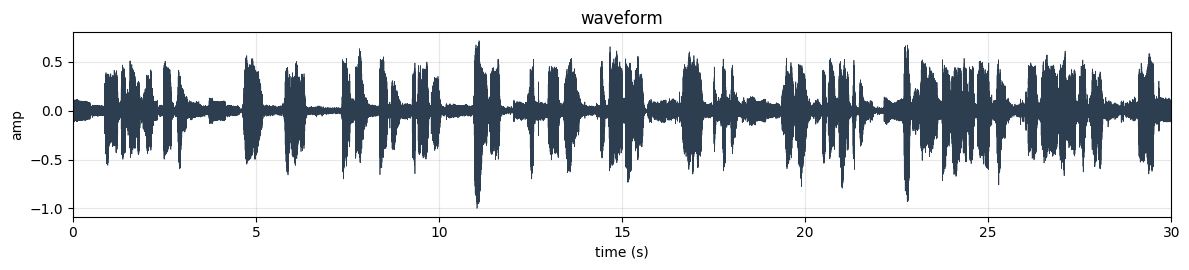

In [15]:
preview_sec = min(30.0, duration_sec)
n_preview = int(preview_sec * sample_rate)
times = np.arange(n_preview) / sample_rate
amps = waveform[0, :n_preview].numpy()

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.plot(times, amps, lw=0.5, color="#2c3e50")
ax.set(xlim=(0, preview_sec), xlabel="time (s)", ylabel="amp", title="waveform")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [37]:
vad_model = load_silero_vad()
vad_audio = waveform.squeeze(0).cpu()

raw_timestamps = get_speech_timestamps(
    vad_audio, vad_model, sampling_rate=sample_rate, return_seconds=False,
)

print("Number of speech regions:", len(raw_timestamps))

Number of speech regions: 32


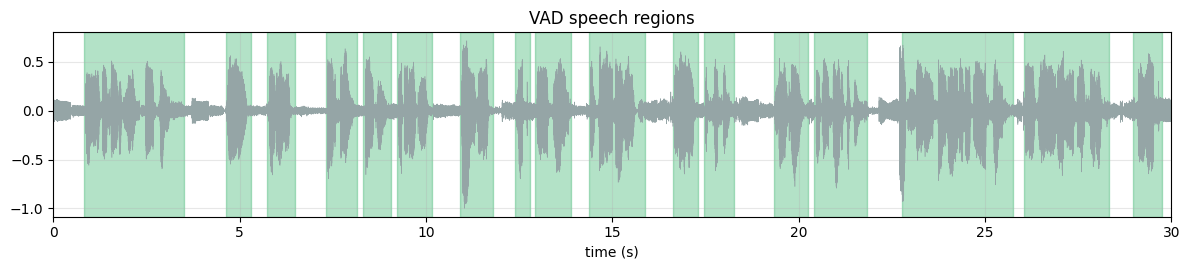

In [17]:
vad_starts = np.array([ts["start"] / sample_rate for ts in raw_timestamps])
vad_ends = np.array([ts["end"] / sample_rate for ts in raw_timestamps])

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.plot(times, amps, lw=0.4, color="#95a5a6")
for start, end in zip(vad_starts, vad_ends):
    if start >= preview_sec:
        break
    ax.axvspan(start, min(end, preview_sec), color="#27ae60", alpha=0.35)
ax.set(xlim=(0, preview_sec), xlabel="time (s)", title="VAD speech regions")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
@dataclass
class SpeechSegment:
    start: float
    end: float

    @property
    def duration(self) -> float:
        return self.end - self.start


speech_segments = [SpeechSegment(float(s), float(e)) for s, e in zip(vad_starts, vad_ends)]

speech_segments = [
    seg for seg in speech_segments if MAX_SPEECH_SEC >= seg.duration >= MIN_SPEECH_SEC
]

print("Number of segments after filtering:", len(speech_segments))

Number of segments after filtering: 31


In [24]:
import os

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

encoder = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir=r"D:\speechbrain_models\spkrec-ecapa-voxceleb",
    run_opts={"device": DEVICE},
)

encoder.eval()

print("Encoder loaded successfully")

Encoder loaded successfully


In [39]:
embeddings_list = []

for seg in speech_segments:
    i0 = int(seg.start * sample_rate)
    i1 = int(seg.end * sample_rate)

    with torch.inference_mode():
        emb = encoder.encode_batch(
            waveform[:, i0:i1].to(DEVICE)
        )

        emb = emb.squeeze().float()

    embeddings_list.append(
        emb.cpu().numpy()
    )

embeddings = np.stack(embeddings_list)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (31, 192)


In [21]:
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda:0


In [22]:
import os

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

encoder = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir=r"D:\speechbrain_models\spkrec-ecapa-voxceleb",
    run_opts={"device": DEVICE},
)

encoder.eval()

print("Encoder loaded successfully")

Encoder loaded successfully


Estimated number of speakers: 3


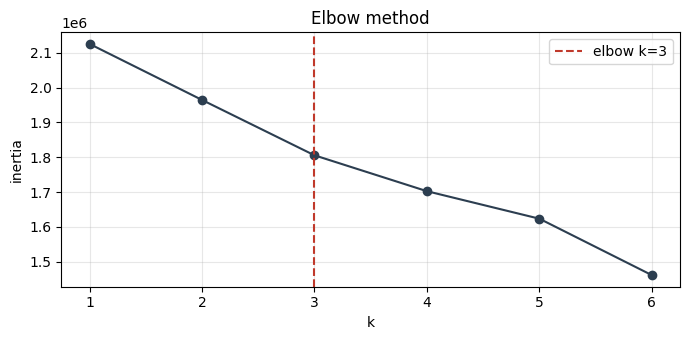

In [40]:
k_max = min(MAX_SPEAKERS, len(embeddings))
ks = list(range(1, k_max + 1))
inertias: list[float] = []
models: dict[int, KMeans] = {}

for k in ks:
    m = KMeans(n_clusters=k, random_state=KMEANS_SEED, n_init=10)
    m.fit(embeddings)
    models[k] = m
    inertias.append(float(m.inertia_))


def choose_k_elbow(ks_: list[int], inertias_: list[float]) -> int:
    if len(ks_) == 1:
        return ks_[0]

    x = np.asarray(ks_, dtype=np.float64)
    y = np.asarray(inertias_, dtype=np.float64)

    x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

    p1 = np.array([x_n[0], y_n[0]])
    line = np.array([x_n[-1], y_n[-1]]) - p1

    line_len = np.linalg.norm(line) + 1e-12

    dists = [
        abs(line[0] * (p1[1] - yi) - line[1] * (p1[0] - xi)) / line_len
        for xi, yi in zip(x_n, y_n)
    ]

    return ks_[int(np.argmax(dists))]


best_k = choose_k_elbow(ks, inertias)

print("Estimated number of speakers:", best_k)

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(ks, inertias, "o-", color="#2c3e50")
ax.axvline(best_k, color="#c0392b", ls="--", label=f"elbow k={best_k}")

ax.set(
    xlabel="k",
    ylabel="inertia",
    title="Elbow method",
    xticks=ks
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

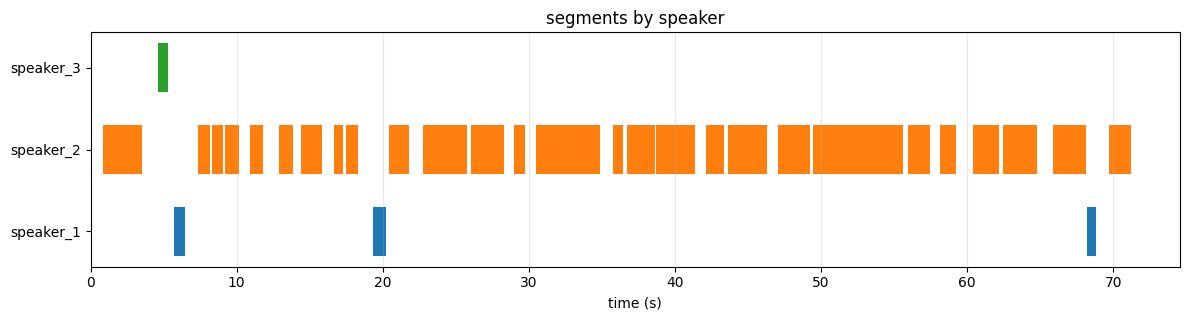

In [27]:
kmeans = models[best_k]
cluster_ids = kmeans.labels_

segment_labels = [f"speaker_{cid + 1}" for cid in cluster_ids]
unique_labels = sorted(set(segment_labels), key=lambda s: int(s.split("_")[1]))
cmap = plt.get_cmap("tab10")
color_map = {lab: cmap(i % 10) for i, lab in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(12, 0.6 * len(unique_labels) + 1.5))
y_pos = {lab: i for i, lab in enumerate(unique_labels)}
for seg, lab in zip(speech_segments, segment_labels):
    ax.barh(y_pos[lab], seg.duration, left=seg.start, height=0.6, color=color_map[lab])
ax.set_yticks(list(y_pos.values()), list(y_pos.keys()))
ax.set(xlabel="time (s)", xlim=(0, duration_sec), title="segments by speaker")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


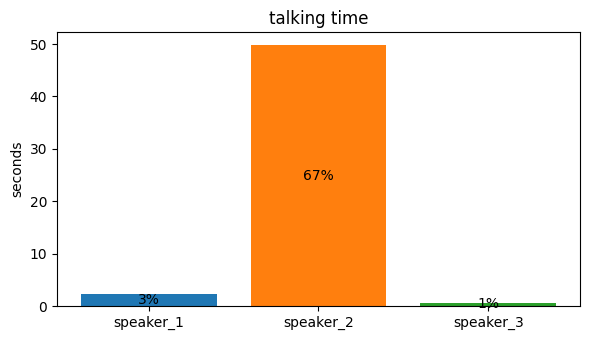

In [28]:
talk_sec = {
    lab: sum(seg.duration for seg, label in zip(speech_segments, segment_labels) if label == lab)
    for lab in unique_labels
}

fig, ax = plt.subplots(figsize=(best_k * 2, 3.5))
labs = list(talk_sec.keys())
vals = [talk_sec[lab] for lab in labs]
ax.bar(labs, vals, color=[color_map[lab] for lab in labs])
ax.set(ylabel="seconds", title="talking time")
for i, v in enumerate(vals):
    ax.text(i, v / 2, f"{100 * v / duration_sec:.0f}%", ha="center", va="center")
plt.tight_layout()
plt.show()


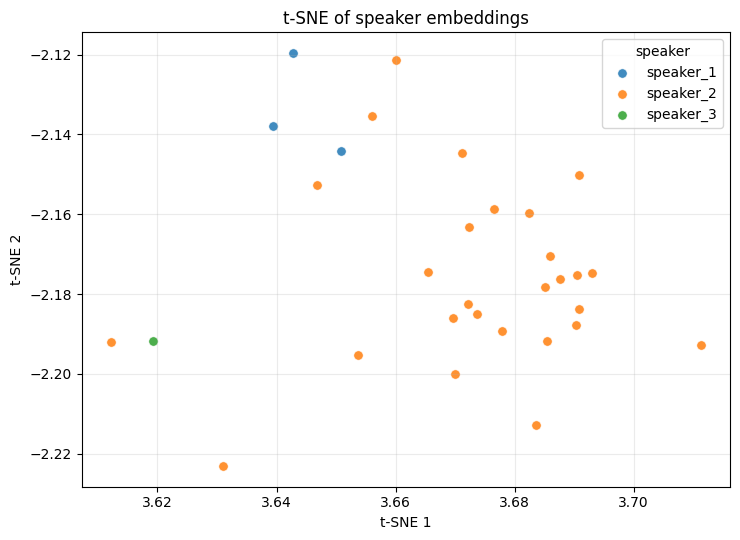

In [29]:
perplexity = min(30, max(2, len(embeddings) - 1))
coords = TSNE(
    n_components=2, metric="cosine", perplexity=perplexity, random_state=KMEANS_SEED, init="pca",
).fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for lab in unique_labels:
    mask = np.array([label == lab for label in segment_labels])
    ax.scatter(
        coords[mask, 0], coords[mask, 1], c=[color_map[lab]], label=lab,
        s=45, alpha=0.85, edgecolors="white", linewidths=0.4,
    )
ax.set(title="t-SNE of speaker embeddings", xlabel="t-SNE 1", ylabel="t-SNE 2")
ax.legend(title="speaker")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [30]:
for lab in unique_labels:
    idxs = [i for i, label in enumerate(segment_labels) if label == lab]
    pick = random.sample(idxs, k=min(N_PLAY_PER_SPEAKER, len(idxs)))
    print(f"\n{lab} -> " + ", ".join(f"seg_{i}" for i in pick))
    for i in pick:
        seg = speech_segments[i]
        i0 = int(seg.start * sample_rate)
        i1 = int(seg.end * sample_rate)
        clip = waveform[0, i0:i1].numpy()
        print(f"  seg_{i}: {seg.start:.2f}s -> {seg.end:.2f}s ({seg.duration:.2f}s)")
        display(Audio(clip, rate=sample_rate))



speaker_1 -> seg_2, seg_29, seg_11
  seg_2: 5.73s -> 6.49s (0.76s)


  seg_29: 68.23s -> 68.80s (0.57s)


  seg_11: 19.33s -> 20.25s (0.92s)



speaker_2 -> seg_14, seg_4, seg_13
  seg_14: 26.05s -> 28.32s (2.27s)


  seg_4: 8.32s -> 9.05s (0.73s)


  seg_13: 22.79s -> 25.76s (2.97s)



speaker_3 -> seg_1
  seg_1: 4.64s -> 5.31s (0.67s)


In [31]:
def label_segment_speaker(seg_start: float, seg_end: float) -> str | None:
    best_overlap = 0.0
    best_label = None
    for seg, label in zip(speech_segments, segment_labels):
        overlap = min(seg_end, seg.end) - max(seg_start, seg.start)
        if overlap > best_overlap:
            best_overlap = overlap
            best_label = label
    return best_label


speaker_labeled_transcript = []
for seg in result["segments"]:
    start = seg["start"]
    end = start + seg["duration"]
    label = label_segment_speaker(start, end) or "unknown"
    speaker_labeled_transcript.append(f"[{label}] {seg['text'].strip()}")

print("\n".join(speaker_labeled_transcript[:40]))


[speaker_2] conversation between two friends hello how are you I'm fine thank you what
[speaker_2] about you I'm good but you look worried is there any problem no no it's okay
[speaker_2] don't worry you can share it with me actually I'm worried about my exams
[speaker_2] there is only one week left for it so what I think I have not studied anything
[speaker_2] I'm feeling nervous oh just focus on your studies and you won't face any
[speaker_2] problems that's the problem I can't concentrate on my studies I too had the
[speaker_2] same problem and hence I started meditating it has a drastic effect on my
[speaker_2] concentration power will it really work definitely I will surely follow it thank
[speaker_2] you so much for your advice it's okay I will meet you soon bye bye take care
